# γ-β Residual-Stream Bridge — Reproducible Analysis

P0-1 evidence companion. Reproduces:
1. Per-trace amplitude paired histogram (Instruct vs Thinking, by base-correct sub-group).
2. Per-token amplitude trajectory along Thinking trace (anchor `a-S1` vs neutral `d` arm).
3. Bootstrap CI bar chart per (arm × base sub-group).

**Verdict — Alt-1 falsified**: Thinking trace amplitude on the K=8 anchor subspace at L=33 *is* larger than Instruct (Δ=+45, 1.24×, paired bootstrap CI excludes 0), but the same magnitude effect appears on the neutral `d` arm — Thinking-mode dynamics broadly activate the calibration subspace, NOT anchor-specifically. Bridge to §6 mechanism not established at this calibration scope.

Inputs (gitignored, regenerable via spec §8 commands):
- `outputs/gamma_beta_bridge/qwen3-vl-8b-instruct/instruct_<ts>/amplitude_per_trace.jsonl`
- `outputs/gamma_beta_bridge/qwen3-vl-8b-thinking/thinking_<ts>/amplitude_per_trace.jsonl`
- `docs/insights/_data/gamma_beta_bridge_amplitude_per_trace.csv`

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('.').resolve()
while not (PROJECT_ROOT / 'configs').is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
FIG_DIR = PROJECT_ROOT / 'docs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

csv_path = PROJECT_ROOT / 'docs/insights/_data/gamma_beta_bridge_amplitude_per_trace.csv'
df = pd.read_csv(csv_path)
print(f'loaded {len(df)} rows, columns={list(df.columns)}')
df.head()

loaded 1091 rows, columns=['sample_instance_id', 'condition', 'instruct_mean_amp', 'instruct_max_amp', 'instruct_n_tokens', 'thinking_mean_amp', 'thinking_max_amp', 'thinking_n_tokens', 'delta', 'ratio', 'base_correct']


,sample_instance_id,condition,instruct_mean_amp,instruct_max_amp,instruct_n_tokens,thinking_mean_amp,thinking_max_amp,thinking_n_tokens,delta,ratio,base_correct
0,2_2_stratified,target_plus_irrelevant_number_S1,182.805557,224.876236,10,238.766205,300.070984,122,55.960648,1.306121,True
1,2_2_stratified,target_plus_irrelevant_neutral,181.671814,227.205368,10,234.364029,298.656250,136,52.692215,1.290041,True
2,3_3_stratified,target_plus_irrelevant_neutral,165.106842,207.979980,9,214.664673,284.344055,512,49.557831,1.300156,NaN
3,4_4_stratified,target_plus_irrelevant_number_S1,192.007141,207.843979,7,238.581818,298.216614,471,46.574677,1.242567,True
4,4_4_stratified,target_plus_irrelevant_neutral,191.866760,207.243698,7,238.301788,300.292542,337,46.435028,1.242017,True


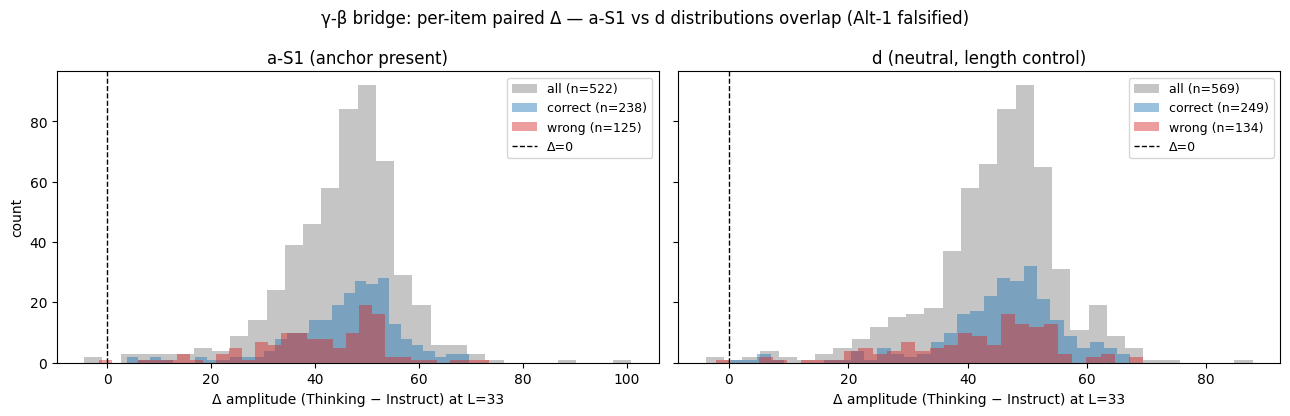

In [2]:
# Paired Δ histogram: a-S1 vs d (control), by base_correct sub-group.
# IF the bridge claim were true, a-S1 distribution would shift right relative to d.
# Observation: distributions sit on top of each other.

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, cond, title in zip(axes,
                            ['target_plus_irrelevant_number_S1', 'target_plus_irrelevant_neutral'],
                            ['a-S1 (anchor present)', 'd (neutral, length control)']):
    sub = df[df['condition'] == cond]
    for base_mode, color in [('all', 'tab:gray'), ('correct', 'tab:blue'), ('wrong', 'tab:red')]:
        if base_mode == 'all':
            data = sub['delta'].dropna()
        elif base_mode == 'correct':
            data = sub[sub['base_correct'] == True]['delta'].dropna()
        else:
            data = sub[sub['base_correct'] == False]['delta'].dropna()
        ax.hist(data, bins=30, alpha=0.45, label=f'{base_mode} (n={len(data)})', color=color)
    ax.axvline(0, color='black', lw=1, ls='--', label='Δ=0')
    ax.set_title(title)
    ax.set_xlabel('Δ amplitude (Thinking − Instruct) at L=33')
    ax.legend(fontsize=9)
axes[0].set_ylabel('count')
fig.suptitle('γ-β bridge: per-item paired Δ — a-S1 vs d distributions overlap (Alt-1 falsified)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'gamma_beta_bridge_paired_delta.png', dpi=150)
plt.show()

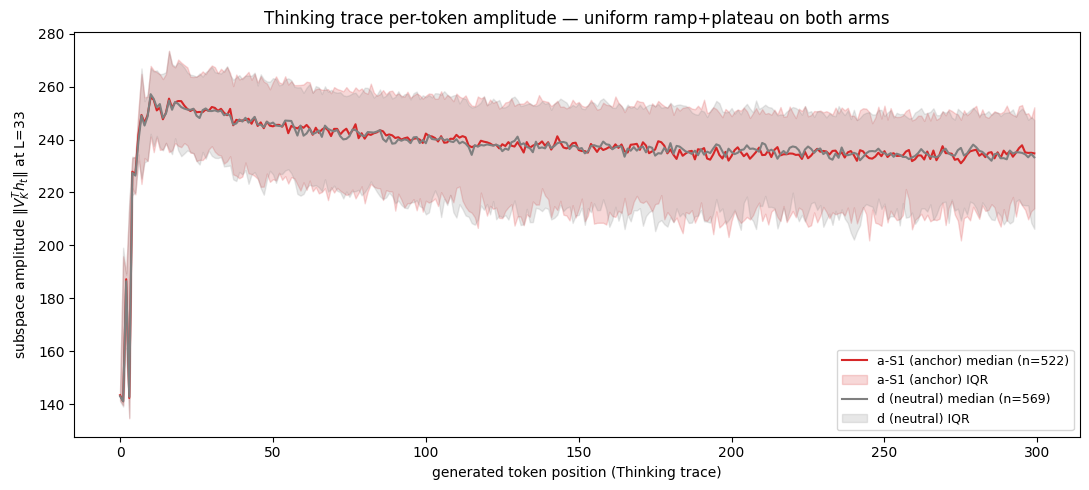

In [3]:
# Per-token Thinking trajectory at L=33.
# Thinking trace amplitude ramps from prefill ~143 to plateau ~245 within ~10 tokens,
# then stable. The ramp-and-plateau is identical between a-S1 and d — IQR overlaps everywhere.

thinking_amp_paths = sorted((PROJECT_ROOT / 'outputs/gamma_beta_bridge/qwen3-vl-8b-thinking').glob('thinking_*/amplitude_per_trace.jsonl'))
if not thinking_amp_paths:
    raise FileNotFoundError('no Thinking amplitude jsonl found — re-run Phase C4')
thinking_amp_path = thinking_amp_paths[-1]

a_traces, d_traces = [], []
with thinking_amp_path.open() as f:
    for line in f:
        r = json.loads(line)
        per_token = r['amplitude_per_layer'].get('33', {}).get('per_token')
        if not per_token: continue
        if r['condition'] == 'target_plus_irrelevant_number_S1':
            a_traces.append(per_token)
        elif r['condition'] == 'target_plus_irrelevant_neutral':
            d_traces.append(per_token)

def percentile_band(traces, max_len=300):
    arr = np.full((len(traces), max_len), np.nan)
    for i, t in enumerate(traces):
        n = min(len(t), max_len)
        arr[i, :n] = t[:n]
    med = np.nanmedian(arr, axis=0)
    q25 = np.nanquantile(arr, 0.25, axis=0)
    q75 = np.nanquantile(arr, 0.75, axis=0)
    return med, q25, q75

fig, ax = plt.subplots(figsize=(11, 5))
for traces, label, color in [(a_traces, 'a-S1 (anchor)', 'tab:red'), (d_traces, 'd (neutral)', 'tab:gray')]:
    med, q25, q75 = percentile_band(traces, max_len=300)
    x = np.arange(len(med))
    ax.plot(x, med, color=color, lw=1.5, label=f'{label} median (n={len(traces)})')
    ax.fill_between(x, q25, q75, color=color, alpha=0.18, label=f'{label} IQR')
ax.set_xlabel('generated token position (Thinking trace)')
ax.set_ylabel('subspace amplitude $\\|V_K^T h_t\\|$ at L=33')
ax.set_title('Thinking trace per-token amplitude — uniform ramp+plateau on both arms')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'gamma_beta_bridge_per_token_trajectory.png', dpi=150)
plt.show()

In [4]:
# Re-derived bootstrap CI summary table (cross-check with summary MD).

def bootstrap_ci(arr, B=10000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    n = len(arr)
    if n == 0: return float('nan'), float('nan')
    idx = rng.integers(0, n, size=(B, n))
    means = arr[idx].mean(axis=1)
    return float(np.quantile(means, alpha/2)), float(np.quantile(means, 1-alpha/2))

rows = []
for cond, cond_label in [('target_plus_irrelevant_number_S1', 'a-S1'),
                          ('target_plus_irrelevant_neutral', 'd (control)')]:
    sub = df[df['condition'] == cond]
    for base_mode in ['all', 'correct', 'wrong']:
        if base_mode == 'all': data = sub
        elif base_mode == 'correct': data = sub[sub['base_correct'] == True]
        else: data = sub[sub['base_correct'] == False]
        deltas = data['delta'].dropna().values
        if len(deltas) == 0:
            rows.append([cond_label, base_mode, 0, None, None, None, None]); continue
        lo, hi = bootstrap_ci(deltas)
        ratio = (data['thinking_mean_amp'].mean() / data['instruct_mean_amp'].mean())
        rows.append([cond_label, base_mode, len(deltas), float(deltas.mean()), lo, hi, ratio])

summary = pd.DataFrame(rows, columns=['arm', 'base', 'n', 'mean_delta', 'ci_lo', 'ci_hi', 'ratio'])
summary

,arm,base,n,mean_delta,ci_lo,ci_hi,ratio
0,a-S1,all,522,45.114972,44.133923,46.087966,1.243380
1,a-S1,correct,238,45.982993,44.550722,47.343953,1.245957
2,a-S1,wrong,125,40.870127,38.564054,43.069845,1.215090
3,d (control),all,569,44.675323,43.734653,45.602978,1.240708
4,d (control),correct,249,45.518926,44.103073,46.889112,1.243246
5,d (control),wrong,134,41.258802,38.980327,43.438285,1.216746


In [5]:
# Difference-in-differences (DiD) per sample_instance_id paired between a-S1 and d.
# Decisive measurement: if bridge claim true, DiD > 0 with CI excluding 0.
# Observation: DiD ≈ +0.5 with std ~5–7 — noise floor.

a = df[df['condition'] == 'target_plus_irrelevant_number_S1']
d = df[df['condition'] == 'target_plus_irrelevant_neutral']
merged = a[['sample_instance_id', 'delta', 'base_correct']].merge(
    d[['sample_instance_id', 'delta']], on='sample_instance_id', suffixes=('_a', '_d'))
merged['DiD'] = merged['delta_a'] - merged['delta_d']

did_table = merged.groupby('base_correct', dropna=False)['DiD'].agg(['mean', 'std', 'count']).reset_index()
did_table.loc[len(did_table)] = ['ALL', merged['DiD'].mean(), merged['DiD'].std(), len(merged)]
did_table

,base_correct,mean,std,count
0,True,0.395108,4.652629,238
1,NaN,0.865342,5.186866,159
2,False,0.114589,7.420208,125
3,ALL,0.471166,5.584879,522
